# Nettoyage Dataset Pokémon


#### Import


In [1245]:
import pandas as pd
import numpy as np
from pathlib import Path as Pathlib
from IPython.display import HTML, display, Image
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
lignes_a_tester = [362, 267, 490, 493, 474, 197, 325, 702, 738]
pokemon_a_tester = [720, 479, 3, 469, 122, 163, 386, 413, 439, 487, 492, 555, 641, 645, 647, 648, 669, 678, 681, 710, 711, 718, 410]

#### Transpose la DataFrame

In [1246]:
df = pd.read_csv("data/Pokemon_dataset.csv", sep=";").T
# df = pd.read_csv("data/Pokemon_dataset.csv", sep=";", index_col=0).T
print('✅')

✅


#### Suppression de la 1ere ligne

In [1247]:
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)

df.columns.name = "Id"
old_df = df.copy()
print('✅')

✅


#### Trier par '#'

In [1248]:
df['#'] = df['#'].astype(int)
df = df.sort_values(by='#')

def afficher_test(lignes = []):
    if not lignes:
        lignes = lignes_a_tester
    ligne_sort = sorted(lignes)
    display(df.loc[ligne_sort])

def afficher_pokemon(num = []):
    if not num:
        num = pokemon_a_tester
    num_sort = sorted(num)
    display(df[df['#'].isin(num_sort)])

afficher_pokemon()
print('✅')

Id,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Speed,Generation,Legendary,Types
151,3,venusaur,525,80.0,82,101.2195,100 / 100,80.0,1.0,False,"Grass, Poison"
325,3,VenusaurMega Venusaur,625,80.0,100,123.0,122 / 120,80.0,1.0,False,"Grass, Poison"
204,122,Mr. Mime,460,40.0,45,144.4444,100 / 120,90.0,1.0,False,"Psychic, Fairy"
318,163,Hoothoot,262,60.0,30,100.0,36 / 56,50.0,2.0,False,"Normal, Flying"
419,386,DeoxysAttack Forme,600,50.0,180,11.1111,180 / 20,150.0,3.0,True,"Psychic,"
188,386,DEOXYSSPEED FORME,600,50.0,95,94.7368,95 / 90,180.0,3.0,True,"Psychic,"
80,386,DeoxysNormal Forme,600,50.0,150,33.3333,150 / 50,150.0,3.0,True,"Psychic,"
469,386,DeoxysDefense Forme,600,50.0,70,228.5714,70 / 160,90.0,3.0,True,"Psychic,"
717,410,Shieldon,350,30.0,a110,280.9524,42 / 88,30.0,4.0,False,"Rock, Steel"
664,413,wormadamtrash cloak,424,60.0,69,137.6812,69 / 95,36.0,4.0,False,"Bug, Steel"


✅


#### Afficher les infos


In [1249]:
print(df.info())
print('✅')

<class 'pandas.DataFrame'>
Index: 800 entries, 374 to 406
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   #                    800 non-null    int64
 1   Name                 800 non-null    str  
 2   Total                800 non-null    str  
 3   HP                   773 non-null    str  
 4   Attack               775 non-null    str  
 5   Defense % of Attack  800 non-null    str  
 6   Sp. Atk / Sp. Def    800 non-null    str  
 7   Speed                757 non-null    str  
 8   Generation           761 non-null    str  
 9   Legendary            800 non-null    str  
 10  Types                800 non-null    str  
dtypes: int64(1), str(10)
memory usage: 75.0 KB
None
✅


#### Couper "Sp. Atk / Sp. Def"

In [1250]:
df["Sp. Atk / Sp. Def"] = (
    df["Sp. Atk / Sp. Def"]
    .str.replace("//", "/", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

df["Sp. Atk / Sp. Def"] = df["Sp. Atk / Sp. Def"].str.replace(
    r"^\s*(\d+)\s*/\s*(\d+)\s*/\s*\d+\s*$",
    r"\1 / \2",
    regex=True
)

df_sp_atk = df["Sp. Atk / Sp. Def"].str.split(" / ", expand=True)[0]
df_sp_def = df["Sp. Atk / Sp. Def"].str.split(" / ", expand=True)[1]

index_sp_atk_def = df.columns.get_loc("Sp. Atk / Sp. Def")

df.insert(index_sp_atk_def + 1, "Sp. Atk", df_sp_atk)
df.insert(index_sp_atk_def + 2, "Sp. Def", df_sp_def)
print('✅')

✅


#### Nettoyage des int

In [1251]:
def regex_garder_numerique(df, columns=[]):
    for name in columns:
        df[name] = df[name].str.replace(r"[^0-9.]", "", regex=True)
    return df

df = regex_garder_numerique(df, ["HP", "Attack", "Defense % of Attack", "Speed", "Generation", "Sp. Atk", "Sp. Def"])
print('✅')

✅


#### Nettoyer les "Types"

In [1252]:
def regex_nettoyage_types(df):
    df["Types"] = df["Types"].str.replace(r"\s*,\s*$", "", regex=True)
    df["Types"] = df["Types"].str.title()

    return df

df = regex_nettoyage_types(df)
print('✅')

✅


#### Nettoyer les "Names"

In [1253]:
def nettoyer_name(name):
    formes = [
        # Forme
        "therian",
        "incarnate",
        "origin",
        "altered",
        "land",
        "sky",
        "ordinary",
        "resolute",
        "aria",
        "pirouette",
        "blade",
        "shield",
        "50%",
        "attack",
        "speed",
        "normal",
        "defense",
        # Mode
        "zen",
        "standard",
        # Size
        "average",
        "large",
        "small",
        "super",
        # Cloak
        "plant",
        "sandy",
        "trash",
    ]

    name_lower = name.lower()

    if "size" not in name_lower and "forme" not in name_lower and "cloak" not in name_lower and "mode" not in name_lower:
        return name
    
    for forme in formes:
        index = name_lower.find(forme)

        if index > 0:
            return name[:index] + " " + name[index:]

    return name

def supprimer_nom_repete(name):
    name_lower = name.lower()
    name_split = name_lower.split()

    debut = name_split[0]
    nom_final = ""

    if name_lower == "hoothoot":
        return name_lower
    
    if len(debut) % 2 == 0:
        milieu = len(debut) // 2
        gauche = debut[:milieu]
        droite = debut[milieu:]
        if gauche == droite:
            nom_final = gauche

    if len(name_split) < 2:
        if not nom_final:
            return name_lower
        return nom_final
    
    nom = name_split[1]
    for value in name_split[1:]:
        debut_split = debut.split(value)
        if debut_split[0] == '':
            nom_final = nom + " " + debut_split[1]
        elif not nom_final:
            return name_lower
        else:
            nom_final = nom_final + " " + value 

    return nom_final
  
df_last_name = df["Name"].copy()
index_name = df.columns.get_loc("Name")
df.insert(index_name + 1, "Last Name", df_last_name)

df["Name"] = df["Name"].apply(nettoyer_name)
df["Name"] = df["Name"].apply(supprimer_nom_repete)
df["Name"] = df["Name"].str.title()
afficher_pokemon()

print('✅')

Id,#,Name,Last Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types
151,3,Venusaur,venusaur,525,80.0,82,101.2195,100 / 100,100,100,80.0,1.0,False,"Grass, Poison"
325,3,Venusaur Mega,VenusaurMega Venusaur,625,80.0,100,123.0,122 / 120,122,120,80.0,1.0,False,"Grass, Poison"
204,122,Mr. Mime,Mr. Mime,460,40.0,45,144.4444,100 / 120,100,120,90.0,1.0,False,"Psychic, Fairy"
318,163,Hoothoot,Hoothoot,262,60.0,30,100.0,36 / 56,36,56,50.0,2.0,False,"Normal, Flying"
419,386,Deoxys Attack Forme,DeoxysAttack Forme,600,50.0,180,11.1111,180 / 20,180,20,150.0,3.0,True,Psychic
188,386,Deoxys Speed Forme,DEOXYSSPEED FORME,600,50.0,95,94.7368,95 / 90,95,90,180.0,3.0,True,Psychic
80,386,Deoxys Normal Forme,DeoxysNormal Forme,600,50.0,150,33.3333,150 / 50,150,50,150.0,3.0,True,Psychic
469,386,Deoxys Defense Forme,DeoxysDefense Forme,600,50.0,70,228.5714,70 / 160,70,160,90.0,3.0,True,Psychic
717,410,Shieldon,Shieldon,350,30.0,110,280.9524,42 / 88,42,88,30.0,4.0,False,"Rock, Steel"
664,413,Wormadam Trash Cloak,wormadamtrash cloak,424,60.0,69,137.6812,69 / 95,69,95,36.0,4.0,False,"Bug, Steel"


✅


#### Changer la "Generation" du Pokémon

In [1254]:
df["Generation"] = df["Generation"].bfill()
print('✅')

✅


#### Modification des types des colonnes

In [1255]:
df["Total"] = df["Total"].astype(float)
df["HP"] = df["HP"].astype(float)
df["Attack"] = df["Attack"].astype(float)
df["Defense % of Attack"] = df["Defense % of Attack"].astype(float)
df["Speed"] = df["Speed"].astype(float)
df["Generation"] = df["Generation"].astype(float)
df["Sp. Atk"] = df["Sp. Atk"].astype(float)
df["Sp. Def"] = df["Sp. Def"].astype(float)
df["Legendary"] = df["Legendary"].map({"True": True, "False": False}).astype(bool)
types = pd.concat([df.dtypes, old_df.dtypes], axis=1, keys=["df", "old_df"])
print(types)
print('✅')

                          df old_df
Id                                 
#                      int64    str
Name                     str    str
Last Name                str    NaN
Total                float64    str
HP                   float64    str
Attack               float64    str
Defense % of Attack  float64    str
Sp. Atk / Sp. Def        str    str
Sp. Atk              float64    NaN
Sp. Def              float64    NaN
Speed                float64    str
Generation           float64    str
Legendary               bool    str
Types                    str    str
✅


#### Calculer "Defense"

In [1256]:
index_attack = df.columns.get_loc("Attack")
afficher_test()

df_defense = ((df["Defense % of Attack"] / 100) * df["Attack"]).round()
df.insert(index_attack + 1, "Defense", df_defense)

afficher_test()
print('✅')

Id,#,Name,Last Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types
197,167,Spinarak,SPINARAK,250.0,NaN,60.0,66.6667,40 / 40,40.0,40.0,NaN,2.0,False,"Bug, Poison"
267,15,Beedrill,BEEDRILL,395.0,15925.0,90.0,44.4444,45 / 80,45.0,80.0,75.0,1.0,False,"Bug, Poison"
325,3,Venusaur Mega,VenusaurMega Venusaur,625.0,80.0,100.0,123.0000,122 / 120,122.0,120.0,80.0,1.0,False,"Grass, Poison"
362,63,Abra,Abra,310.0,25.0,NaN,75.0000,105 / 55,105.0,55.0,90.0,1.0,False,Psychic
474,328,Trapinch,TRAPINCH,290.0,NaN,NaN,45.0000,45 / 45,45.0,45.0,10.0,3.0,False,Ground
490,107,Hitmonchan,HITMONCHAN,455.0,50.0,105.0,75.2381,35 / 110,35.0,110.0,76.0,1.0,False,Fighting
493,479,Rotom Fan,ROTOMFAN ROTOM,520.0,12250.0,65.0,164.6154,105 / 107,105.0,107.0,NaN,4.0,False,"Electric, Flying"
702,469,Yanmega,Yanmega,515.0,86.0,76.0,113.1579,116 / 56,116.0,56.0,95.0,4.0,False,"Bug, Flying"
738,334,Altaria Mega,AltariaMega Altaria,590.0,75.0,110.0,100.0000,110 / 105,110.0,105.0,80.0,3.0,False,"Dragon, Fairy"


Id,#,Name,Last Name,Total,HP,Attack,Defense,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types
197,167,Spinarak,SPINARAK,250.0,NaN,60.0,40.0,66.6667,40 / 40,40.0,40.0,NaN,2.0,False,"Bug, Poison"
267,15,Beedrill,BEEDRILL,395.0,15925.0,90.0,40.0,44.4444,45 / 80,45.0,80.0,75.0,1.0,False,"Bug, Poison"
325,3,Venusaur Mega,VenusaurMega Venusaur,625.0,80.0,100.0,123.0,123.0000,122 / 120,122.0,120.0,80.0,1.0,False,"Grass, Poison"
362,63,Abra,Abra,310.0,25.0,NaN,NaN,75.0000,105 / 55,105.0,55.0,90.0,1.0,False,Psychic
474,328,Trapinch,TRAPINCH,290.0,NaN,NaN,NaN,45.0000,45 / 45,45.0,45.0,10.0,3.0,False,Ground
490,107,Hitmonchan,HITMONCHAN,455.0,50.0,105.0,79.0,75.2381,35 / 110,35.0,110.0,76.0,1.0,False,Fighting
493,479,Rotom Fan,ROTOMFAN ROTOM,520.0,12250.0,65.0,107.0,164.6154,105 / 107,105.0,107.0,NaN,4.0,False,"Electric, Flying"
702,469,Yanmega,Yanmega,515.0,86.0,76.0,86.0,113.1579,116 / 56,116.0,56.0,95.0,4.0,False,"Bug, Flying"
738,334,Altaria Mega,AltariaMega Altaria,590.0,75.0,110.0,110.0,100.0000,110 / 105,110.0,105.0,80.0,3.0,False,"Dragon, Fairy"


✅


#### Calculer "Stats"

In [1257]:
def calculer_statistiques(df, stats):
    print("--> Stat trop grande ✅")
    for stat in stats:
        df.loc[df[stat] > df["Total"], stat] = np.nan

    print("--> 1 seul NaN ✅")
    masque_stats_nan = df[stats].isna().sum(axis=1) == 1
    for stat in stats:
        stats_nan = masque_stats_nan & df[stat].isna()
        df.loc[stats_nan, stat] = df.loc[stats_nan, "Total"] - df.loc[stats_nan, stats].sum(axis=1)


    print("--> Total érroné ✅")
    total = df[stats].sum(axis=1)
    masques_total_errone = (df[stats].isna().sum(axis=1) == 0) & (total > df["Total"])
    df.loc[masques_total_errone, "Total"] = total[masques_total_errone]

    return df    

df = calculer_statistiques(df, stats)
print('✅')

--> Stat trop grande ✅
--> 1 seul NaN ✅
--> Total érroné ✅
✅


#### Calculer "Ratio"

In [1258]:
stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

def calculer_statistiques_multiple_nan(df, stats, df_ratio):

    masque = df[stats].isna().sum(axis=1) > 1

    reste = df.loc[masque, "Total"] - df.loc[masque, stats].sum(axis=1)
        
    ratios = df_ratio.loc[df.loc[masque, "Types"]]

    ratios.index = df.loc[masque].index

    ratios_nan = ratios.where(df.loc[masque, stats].isna())

    nouveaux_ratios = ratios_nan.div(ratios_nan.sum(axis=1), axis=0)
    
    nouvelles_stats = nouveaux_ratios.mul(reste, axis=0)

    df.loc[masque, stats] = df.loc[masque, stats].fillna(nouvelles_stats.round())

    return df

moyennes_stats = df.groupby(["Types"])[stats].mean()
moyennes_total = df.groupby(["Types"])["Total"].mean()

df_ratio = pd.DataFrame(index=moyennes_stats.index)
df_ratio["HP"] = moyennes_stats["HP"] / moyennes_total
df_ratio["Attack + Defense"] = ((moyennes_stats["Attack"] + moyennes_stats["Defense"]) / moyennes_total)
df_ratio["Sp. Atk"] = moyennes_stats["Sp. Atk"] / moyennes_total
df_ratio["Sp. Def"] = moyennes_stats["Sp. Def"] / moyennes_total
df_ratio["Speed"] = moyennes_stats["Speed"] / moyennes_total

df["Attack + Defense"] = (df["Attack"] + df["Defense"]).where(df["Attack"].notna() & df["Defense"].notna())
new_stats = ["HP", "Attack + Defense", "Sp. Atk", "Sp. Def", "Speed"]

# afficher_test()
df = calculer_statistiques_multiple_nan(df, new_stats, df_ratio)
# afficher_test()
print('✅')

✅


#### Calculer NaN Attack et NaN Defense

In [1259]:
afficher_test()
df.drop(columns=["Attack + Defense"], inplace=True)

attack_defense = ["Attack", "Defense"]
masque_global = df.isna().sum(axis=1) == 2
masque_attack_defense = df[attack_defense].isna().sum(axis=1) == 2

masque = masque_global & masque_attack_defense
reste = df.loc[masque, "Total"] - df.loc[masque, stats].sum(axis=1)

nouvelles_attack = (100 * reste) / (100 + df.loc[masque, "Defense % of Attack"])
nouvelles_defense = reste - nouvelles_attack

df.loc[masque, "Attack"] = df.loc[masque, "Attack"].fillna(nouvelles_attack.round())
df.loc[masque, "Defense"] = df.loc[masque, "Defense"].fillna(nouvelles_defense.round())
afficher_test()


Id,#,Name,Last Name,Total,HP,Attack,Defense,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Attack + Defense
197,167,Spinarak,SPINARAK,250.0,31.0,60.0,40.0,66.6667,40 / 40,40.0,40.0,39.0,2.0,False,"Bug, Poison",100.0
267,15,Beedrill,BEEDRILL,395.0,65.0,90.0,40.0,44.4444,45 / 80,45.0,80.0,75.0,1.0,False,"Bug, Poison",130.0
325,3,Venusaur Mega,VenusaurMega Venusaur,625.0,80.0,100.0,123.0,123.0000,122 / 120,122.0,120.0,80.0,1.0,False,"Grass, Poison",223.0
362,63,Abra,Abra,310.0,25.0,NaN,NaN,75.0000,105 / 55,105.0,55.0,90.0,1.0,False,Psychic,NaN
474,328,Trapinch,TRAPINCH,290.0,53.0,NaN,NaN,45.0000,45 / 45,45.0,45.0,10.0,3.0,False,Ground,137.0
490,107,Hitmonchan,HITMONCHAN,455.0,50.0,105.0,79.0,75.2381,35 / 110,35.0,110.0,76.0,1.0,False,Fighting,184.0
493,479,Rotom Fan,ROTOMFAN ROTOM,520.0,57.0,65.0,107.0,164.6154,105 / 107,105.0,107.0,79.0,4.0,False,"Electric, Flying",172.0
702,469,Yanmega,Yanmega,515.0,86.0,76.0,86.0,113.1579,116 / 56,116.0,56.0,95.0,4.0,False,"Bug, Flying",162.0
738,334,Altaria Mega,AltariaMega Altaria,590.0,75.0,110.0,110.0,100.0000,110 / 105,110.0,105.0,80.0,3.0,False,"Dragon, Fairy",220.0


Id,#,Name,Last Name,Total,HP,Attack,Defense,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types
197,167,Spinarak,SPINARAK,250.0,31.0,60.0,40.0,66.6667,40 / 40,40.0,40.0,39.0,2.0,False,"Bug, Poison"
267,15,Beedrill,BEEDRILL,395.0,65.0,90.0,40.0,44.4444,45 / 80,45.0,80.0,75.0,1.0,False,"Bug, Poison"
325,3,Venusaur Mega,VenusaurMega Venusaur,625.0,80.0,100.0,123.0,123.0000,122 / 120,122.0,120.0,80.0,1.0,False,"Grass, Poison"
362,63,Abra,Abra,310.0,25.0,20.0,15.0,75.0000,105 / 55,105.0,55.0,90.0,1.0,False,Psychic
474,328,Trapinch,TRAPINCH,290.0,53.0,94.0,43.0,45.0000,45 / 45,45.0,45.0,10.0,3.0,False,Ground
490,107,Hitmonchan,HITMONCHAN,455.0,50.0,105.0,79.0,75.2381,35 / 110,35.0,110.0,76.0,1.0,False,Fighting
493,479,Rotom Fan,ROTOMFAN ROTOM,520.0,57.0,65.0,107.0,164.6154,105 / 107,105.0,107.0,79.0,4.0,False,"Electric, Flying"
702,469,Yanmega,Yanmega,515.0,86.0,76.0,86.0,113.1579,116 / 56,116.0,56.0,95.0,4.0,False,"Bug, Flying"
738,334,Altaria Mega,AltariaMega Altaria,590.0,75.0,110.0,110.0,100.0000,110 / 105,110.0,105.0,80.0,3.0,False,"Dragon, Fairy"


#### Séparer les "Types"

In [1260]:
def separer_types(df):
    df[["Type 1", "Type 2"]] = df["Types"].str.split(", ", expand=True) 
    return df

separer_types(df)
print('✅')

✅


#### Corrélation

In [1261]:
print(df[["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]].corr())
print()
print("--> Aucune corrélation flagrante ✅")

Id             HP    Attack   Defense   Sp. Atk   Sp. Def     Speed
Id                                                                 
HP       1.000000  0.417764  0.221362  0.362341  0.380079  0.176640
Attack   0.417764  1.000000  0.435330  0.394236  0.265829  0.380010
Defense  0.221362  0.435330  1.000000  0.209320  0.498408  0.004322
Sp. Atk  0.362341  0.394236  0.209320  1.000000  0.506121  0.473284
Sp. Def  0.380079  0.265829  0.498408  0.506121  1.000000  0.258162
Speed    0.176640  0.380010  0.004322  0.473284  0.258162  1.000000

--> Aucune corrélation flagrante ✅


#### Check "Total"

In [1262]:
afficher_test()

index_attack = df.columns.get_loc("Total")
df_check_total = np.where((df["HP"] + df["Attack"] + df["Defense"] + df["Sp. Atk"] + df["Sp. Def"] + df["Speed"]).round() == df["Total"],'✅', '❌')
df.insert(index_attack + 1, "Check Total", df_check_total)

afficher_test()
print('✅')

Id,#,Name,Last Name,Total,HP,Attack,Defense,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Type 1,Type 2
197,167,Spinarak,SPINARAK,250.0,31.0,60.0,40.0,66.6667,40 / 40,40.0,40.0,39.0,2.0,False,"Bug, Poison",Bug,Poison
267,15,Beedrill,BEEDRILL,395.0,65.0,90.0,40.0,44.4444,45 / 80,45.0,80.0,75.0,1.0,False,"Bug, Poison",Bug,Poison
325,3,Venusaur Mega,VenusaurMega Venusaur,625.0,80.0,100.0,123.0,123.0000,122 / 120,122.0,120.0,80.0,1.0,False,"Grass, Poison",Grass,Poison
362,63,Abra,Abra,310.0,25.0,20.0,15.0,75.0000,105 / 55,105.0,55.0,90.0,1.0,False,Psychic,Psychic,NaN
474,328,Trapinch,TRAPINCH,290.0,53.0,94.0,43.0,45.0000,45 / 45,45.0,45.0,10.0,3.0,False,Ground,Ground,NaN
490,107,Hitmonchan,HITMONCHAN,455.0,50.0,105.0,79.0,75.2381,35 / 110,35.0,110.0,76.0,1.0,False,Fighting,Fighting,NaN
493,479,Rotom Fan,ROTOMFAN ROTOM,520.0,57.0,65.0,107.0,164.6154,105 / 107,105.0,107.0,79.0,4.0,False,"Electric, Flying",Electric,Flying
702,469,Yanmega,Yanmega,515.0,86.0,76.0,86.0,113.1579,116 / 56,116.0,56.0,95.0,4.0,False,"Bug, Flying",Bug,Flying
738,334,Altaria Mega,AltariaMega Altaria,590.0,75.0,110.0,110.0,100.0000,110 / 105,110.0,105.0,80.0,3.0,False,"Dragon, Fairy",Dragon,Fairy


Id,#,Name,Last Name,Total,Check Total,HP,Attack,Defense,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Type 1,Type 2
197,167,Spinarak,SPINARAK,250.0,✅,31.0,60.0,40.0,66.6667,40 / 40,40.0,40.0,39.0,2.0,False,"Bug, Poison",Bug,Poison
267,15,Beedrill,BEEDRILL,395.0,✅,65.0,90.0,40.0,44.4444,45 / 80,45.0,80.0,75.0,1.0,False,"Bug, Poison",Bug,Poison
325,3,Venusaur Mega,VenusaurMega Venusaur,625.0,✅,80.0,100.0,123.0,123.0000,122 / 120,122.0,120.0,80.0,1.0,False,"Grass, Poison",Grass,Poison
362,63,Abra,Abra,310.0,✅,25.0,20.0,15.0,75.0000,105 / 55,105.0,55.0,90.0,1.0,False,Psychic,Psychic,NaN
474,328,Trapinch,TRAPINCH,290.0,✅,53.0,94.0,43.0,45.0000,45 / 45,45.0,45.0,10.0,3.0,False,Ground,Ground,NaN
490,107,Hitmonchan,HITMONCHAN,455.0,✅,50.0,105.0,79.0,75.2381,35 / 110,35.0,110.0,76.0,1.0,False,Fighting,Fighting,NaN
493,479,Rotom Fan,ROTOMFAN ROTOM,520.0,✅,57.0,65.0,107.0,164.6154,105 / 107,105.0,107.0,79.0,4.0,False,"Electric, Flying",Electric,Flying
702,469,Yanmega,Yanmega,515.0,✅,86.0,76.0,86.0,113.1579,116 / 56,116.0,56.0,95.0,4.0,False,"Bug, Flying",Bug,Flying
738,334,Altaria Mega,AltariaMega Altaria,590.0,✅,75.0,110.0,110.0,100.0000,110 / 105,110.0,105.0,80.0,3.0,False,"Dragon, Fairy",Dragon,Fairy


✅


#### Afficher les NaN

In [1263]:
print(df.isna().sum())

Id
#                        0
Name                     0
Last Name                0
Total                    0
Check Total              0
HP                       0
Attack                   0
Defense                  0
Defense % of Attack      0
Sp. Atk / Sp. Def        0
Sp. Atk                  0
Sp. Def                  0
Speed                    0
Generation               0
Legendary                0
Types                    0
Type 1                   0
Type 2                 386
dtype: int64


#### Lignes restantes érronées

In [1264]:
df_check_total_x = df[
    (df["Check Total"] == '❌') 
    # | (df["Name"].str.contains("mega", case=False, na=False))
    # | (df["Name"].str.contains("primal", case=False, na=False))
    # | (df["Name"].str.contains("attack", case=False, na=False))
    # | (df["Name"].str.contains("speed", case=False, na=False))
    # | (df["Name"].str.contains("normal", case=False, na=False))
    # | (df["Name"].str.contains("defense", case=False, na=False))
    # | (df["Name"].str.contains("cloak", case=False, na=False))
    # | (df["Name"].str.contains("rotom", case=False, na=False))
    # | (df["Name"].str.contains("forme", case=False, na=False))
    # | (df["Name"].str.contains("mode", case=False, na=False))
    # | (df["Name"].str.contains("size", case=False, na=False))
    # | (df["Name"].str.contains("hoopa", case=False, na=False))
]

# mask_comp = df["Name"].str.split(" ").apply(len)>1
# mask_rest = df["Name"].apply(lambda x: sum(1 for car in x.split(" ")[0] if car.isupper()))==1
# display(mask_comp)

display(df_check_total_x)


Id,#,Name,Last Name,Total,Check Total,HP,Attack,Defense,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Type 1,Type 2


#### Afficher les statistiques

In [1265]:
print(df.describe())

Id              #      Total          HP      Attack     Defense  \
count  800.000000  800.00000  800.000000  800.000000  800.000000   
mean   362.813750  435.42625   69.243750   79.078750   74.078750   
std    208.343798  120.08251   25.491353   32.445237   32.237775   
min      1.000000  180.00000    1.000000    5.000000    5.000000   
25%    184.750000  330.00000   50.000000   55.000000   50.000000   
50%    364.500000  450.00000   65.000000   75.000000   70.000000   
75%    539.250000  515.00000   80.000000  100.000000   90.000000   
max    721.000000  780.00000  255.000000  190.000000  309.000000   

Id     Defense % of Attack     Sp. Atk     Sp. Def       Speed  Generation  
count           800.000000  800.000000  800.000000  800.000000  800.000000  
mean            105.500082   72.820000   71.902500   68.302500    3.326250  
std              92.373115   32.722294   27.828916   29.061387    1.660801  
min              11.111100   10.000000   20.000000    5.000000    1.000000  
25

#### Gestion des URL

In [1266]:
df["Name Url"] = df["Name"].str.replace("Mega ", "Mega")
df["Name Url"] = df["Name Url"].str.replace("é", "e")
df["Name Url"] = df["Name Url"].str.replace("Mr. ", "Mr.")
df["Name Url"] = df["Name Url"].str.replace(" Jr.", "_Jr")
df["Name Url"] = df["Name Url"].str.replace(" Cloak", "")
df["Name Url"] = df["Name Url"].str.replace("Wormadam Plant", "Wormadam")
df["Name Url"] = df["Name Url"].str.replace(" Forme", "")
df["Name Url"] = df["Name Url"].str.replace("Deoxys Normal", "Deoxys")
df["Name Url"] = df["Name Url"].str.replace("Shaymin Land", "Shaymin")
df["Name Url"] = df["Name Url"].str.replace("Giratina Altered", "Giratina")
df["Name Url"] = df["Name Url"].str.replace(" Mode", "")
df["Name Url"] = df["Name Url"].str.replace(" Incarnate", "")
df["Name Url"] = df["Name Url"].str.replace("Keldeo Ordinary", "Keldeo")
df["Name Url"] = df["Name Url"].str.replace("Darmanitan Standard", "Darmanitan")
df["Name Url"] = df["Name Url"].str.replace("Meloetta Aria", "Meloetta")
df["Name Url"] = df["Name Url"].str.replace("Meowsticmale", "Meowstic")
df["Name Url"] = df["Name Url"].str.replace("Meowsticfemale", "Meowstic-f")
df["Name Url"] = df["Name Url"].str.replace("Aegislash Shield", "Aegislash")
df["Name Url"] = df["Name Url"].str.replace(" Size", "")
df["Name Url"] = df["Name Url"].str.replace("Pumpkaboo Average", "Pumpkaboo")
df["Name Url"] = df["Name Url"].str.replace("Gourgeist Average", "Gourgeist")
df["Name Url"] = df["Name Url"].str.replace("Hoopa Confined", "Hoopa")
df["Name Url"] = df["Name Url"].str.replace("Zygarde 50%", "Zygarde")

df["Name Url"] = df["Name Url"].str.replace(" ", "-")
df["Name Url"] = df["Name Url"].str.replace("♀", "_f")
df["Name Url"] = df["Name Url"].str.replace("♂", "_m")
df["Name Url"] = df["Name Url"].str.replace("'", "")

print("✅")

✅


#### Pokémon

In [1267]:
df_pokemon = pd.read_csv("data/pokemon.csv", sep=",")
df_pokemon["Total"] = df_pokemon["Total"].astype(float)
df_pokemon["HP"] = df_pokemon["HP"].astype(float)
df_pokemon["Attack"] = df_pokemon["Attack"].astype(float)
df_pokemon["Defense"] = df_pokemon["Defense"].astype(float)
df_pokemon["Speed"] = df_pokemon["Speed"].astype(float)
df_pokemon["Generation"] = df_pokemon["Generation"].astype(float)
df_pokemon["Sp. Atk"] = df_pokemon["Sp. Atk"].astype(float)
df_pokemon["Sp. Def"] = df_pokemon["Sp. Def"].astype(float)
df_pokemon["Legendary"] = df_pokemon["Legendary"].map({"True": True, "False": False}).astype(bool)

print('✅')

✅


#### Comparer Résultats

In [1268]:
df = df.sort_values(
    by=["#", "Name"],
    ascending=[True, True]
).reset_index(drop=True)

df_pokemon = df_pokemon.sort_values(
    by=["#", "Name"],
    ascending=[True, True]
).reset_index(drop=True)

def check(df, df_pokemon, columns):

    for column in columns:

        df_check = np.where(
            df[column].round() == df_pokemon[column].round(),
            '<span style="color:green">' + df[column].astype(str) + '</span>',
            '<span style="color:red">' + df_pokemon[column].astype(str) + '</span>'
        )

        # df_check = df_pokemon[column]

        index_col = df.columns.get_loc(column)
        df.insert(index_col + 1, f"Compare {column}", df_check)
    
    return df

all_stats = stats + ["Total"]
df = check(df, df_pokemon, all_stats)

#### Sprites

In [1269]:
# sprite_dir = Pathlib("sprites")
# sprite_shiny_dir = Pathlib("sprites/shiny")
gif_dir = "https://projectpokemon.org/images/normal-sprite/"
gif_shiny_dir = "https://projectpokemon.org/images/shiny-sprite/"

size = 50

# df_sprite = df["#"].apply(
#     lambda x: f'<img src="{(sprite_dir / f"{x}.png").as_posix()}" width="{size}">'
# )
# df_sprite_shiny = df["#"].apply(
#     lambda x: f'<img src="{(sprite_shiny_dir / f"{x}s.png").as_posix()}" width="{size}">'
# )

df_sprite_gif = df["Name Url"].apply(
    lambda x: f'<img src="{gif_dir}{x.lower()}.gif" width="{size}">'
)

df_sprite_shiny_gif = df["Name Url"].apply(
    lambda x: f'<img src="{gif_shiny_dir}{x.lower()}.gif" width="{size}">'
)
df_test = df["Total"].apply(lambda x: f'<span style="color:green">{x}' if x >= 300 else f'<span style="color:red">{x}')

index_hashtag = df.columns.get_loc("#")

# df.insert(index_hashtag + 1, "Sprite", df_sprite)
# df.insert(index_hashtag + 2, "Shiny", df_sprite_shiny)
df.insert(index_hashtag + 1, "Sprite", df_sprite_gif)
df.insert(index_hashtag + 2, "Shiny", df_sprite_shiny_gif)
# df.insert(index_hashtag + 3, "Test", df_test)

#### Supprimer colonnes inutiles

In [1270]:
df.drop(columns=["Defense % of Attack"], inplace=True)
df.drop(columns=["Sp. Atk / Sp. Def"], inplace=True)
# df.drop(columns=["Types"], inplace=True)
df.drop(columns=["Check Total"], inplace=True)
df.drop(columns=["Last Name"], inplace=True)
df.drop(columns=["Name Url"], inplace=True)

print('✅')

✅


#### Pokémon différents

In [1271]:
def afficher_erreurs(df):
    mask = df.astype(str).apply(
        lambda col: col.str.contains("color:red")
    ).any(axis=1)

    display(HTML(df[mask].to_html(escape=False)))
    
afficher_erreurs(df)

Id,#,Sprite,Shiny,Name,Total,Compare Total,HP,Compare HP,Attack,Compare Attack,Defense,Compare Defense,Sp. Atk,Compare Sp. Atk,Sp. Def,Compare Sp. Def,Speed,Compare Speed,Generation,Legendary,Types,Type 1,Type 2
181,167,,,Spinarak,250.0,250.0,31.0,40.0,60.0,60.0,40.0,40.0,40.0,40.0,40.0,40.0,39.0,30.0,2.0,False,"Bug, Poison",Bug,Poison
359,328,,,Trapinch,290.0,290.0,53.0,45.0,94.0,100.0,43.0,45.0,45.0,45.0,45.0,45.0,10.0,10.0,3.0,False,Ground,Ground,NaN
455,410,,,Shieldon,609.0,350.0,30.0,30.0,110.0,42.0,309.0,118.0,42.0,42.0,88.0,88.0,30.0,30.0,4.0,False,"Rock, Steel",Rock,Steel
532,479,,,Rotom Fan,520.0,520.0,57.0,50.0,65.0,65.0,107.0,107.0,105.0,105.0,107.0,107.0,79.0,86.0,4.0,False,"Electric, Flying",Electric,Flying
559,500,,,Emboar,528.0,528.0,85.0,110.0,123.0,123.0,65.0,65.0,100.0,100.0,65.0,65.0,90.0,65.0,5.0,False,"Fire, Fighting",Fire,Fighting
643,582,,,Vanillite,305.0,305.0,43.0,36.0,50.0,50.0,50.0,50.0,65.0,65.0,60.0,60.0,37.0,44.0,5.0,False,Ice,Ice,NaN


#### Supprimer les colonnes de comparaison

In [1272]:
stats.append("Total")
for stat in stats:
    df.drop(columns=[f"Compare {stat}"], inplace=True)

#### Trouver les évolutions

In [1273]:
df_evol = pd.read_csv("data/evolution_long.csv", sep=",")

def set_name(x, df_evol=df_evol):
    if x == "nidoran♀":
        x = "nidoran-f"
    elif x == "nidoran♂":
        x = "nidoran-m"
    obj = df_evol.loc[df_evol["Evolving_to"].apply(lambda y: y in x), "Evolving_from"].values
    if obj.size == 0:
        below_x = x
    else:
        while obj.size > 0:
            below_x = obj[0]
            obj = df_evol.loc[df_evol["Evolving_to"].apply(lambda y: y in below_x), "Evolving_from"].values
    return below_x

ind_name = df.columns.get_loc("Name")
try:
    df.insert(ind_name+1, "Evolution", "")
except ValueError:
    pass

df["Evolution"] = df["Name"].apply(lambda x: set_name(x.lower(), df_evol=df_evol))
df["Evolution"] = df["Evolution"].str.title()

display(HTML(df.head(9).to_html(escape=False)))

Id,#,Sprite,Shiny,Name,Evolution,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Type 1,Type 2
0,1,,,Bulbasaur,Bulbasaur,318.0,45.0,49.0,49.0,65.0,65.0,45.0,1.0,False,"Grass, Poison",Grass,Poison
1,2,,,Ivysaur,Bulbasaur,405.0,60.0,62.0,63.0,80.0,80.0,60.0,1.0,False,"Grass, Poison",Grass,Poison
2,3,,,Venusaur,Bulbasaur,525.0,80.0,82.0,83.0,100.0,100.0,80.0,1.0,False,"Grass, Poison",Grass,Poison
3,3,,,Venusaur Mega,Bulbasaur,625.0,80.0,100.0,123.0,122.0,120.0,80.0,1.0,False,"Grass, Poison",Grass,Poison
4,4,,,Charmander,Charmander,309.0,39.0,52.0,43.0,60.0,50.0,65.0,1.0,False,Fire,Fire,NaN
5,5,,,Charmeleon,Charmander,405.0,58.0,64.0,58.0,80.0,65.0,80.0,1.0,False,Fire,Fire,NaN
6,6,,,Charizard,Charmander,534.0,78.0,84.0,78.0,109.0,85.0,100.0,1.0,False,"Fire, Flying",Fire,Flying
7,6,,,Charizard Mega X,Charmander,634.0,78.0,130.0,111.0,130.0,85.0,100.0,1.0,False,"Fire, Dragon",Fire,Dragon
8,6,,,Charizard Mega Y,Charmander,634.0,78.0,104.0,78.0,159.0,115.0,100.0,1.0,False,"Fire, Flying",Fire,Flying


#### Création du data_pokemon

In [1274]:
df_evolution = df.groupby(["Evolution"])["Name"].value_counts()
evol, name = df_evolution.index[0]

stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

data_pokemon = [stats]

for base, groupe in df.groupby("Evolution", sort=False):
    valeurs = (
        groupe[stats]
        .astype(int)
        .values
        .tolist()
    )

    data_pokemon.append((base, groupe["Name"].tolist(),valeurs))

print(data_pokemon)

[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed'], ('Bulbasaur', ['Bulbasaur', 'Ivysaur', 'Venusaur', 'Venusaur Mega'], [[45, 49, 49, 65, 65, 45], [60, 62, 63, 80, 80, 60], [80, 82, 83, 100, 100, 80], [80, 100, 123, 122, 120, 80]]), ('Charmander', ['Charmander', 'Charmeleon', 'Charizard', 'Charizard Mega X', 'Charizard Mega Y'], [[39, 52, 43, 60, 50, 65], [58, 64, 58, 80, 65, 80], [78, 84, 78, 109, 85, 100], [78, 130, 111, 130, 85, 100], [78, 104, 78, 159, 115, 100]]), ('Squirtle', ['Squirtle', 'Wartortle', 'Blastoise', 'Blastoise Mega'], [[44, 48, 65, 50, 64, 43], [59, 63, 80, 65, 80, 58], [79, 83, 100, 85, 105, 78], [79, 103, 120, 135, 115, 78]]), ('Caterpie', ['Caterpie', 'Metapod', 'Butterfree'], [[45, 30, 35, 20, 20, 45], [50, 20, 55, 25, 25, 30], [60, 45, 50, 90, 80, 70]]), ('Weedle', ['Weedle', 'Kakuna', 'Beedrill', 'Beedrill Mega'], [[40, 35, 30, 20, 20, 50], [45, 25, 50, 25, 25, 35], [65, 90, 40, 45, 80, 75], [65, 150, 40, 15, 80, 145]]), ('Pidgey', ['Pidgey', 'Pidge

#### Graphiques

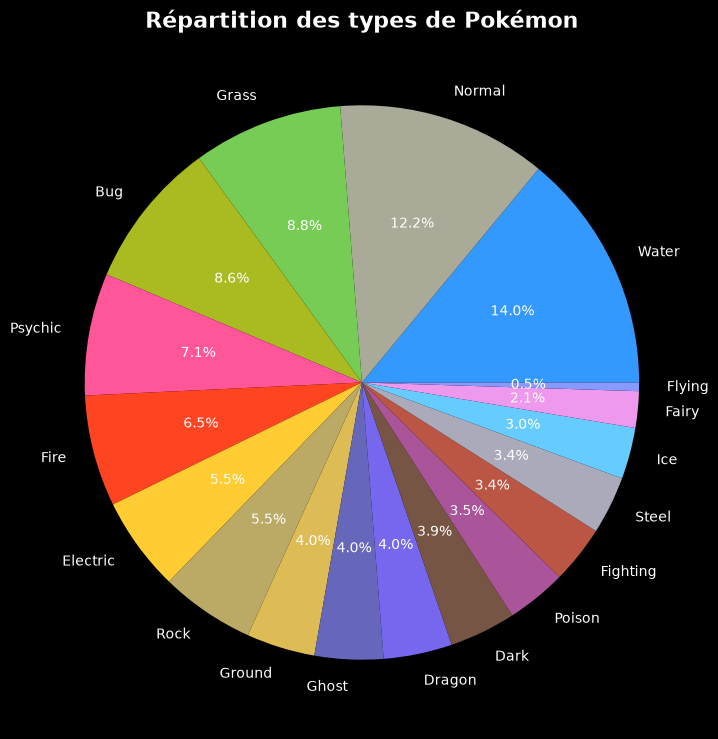

In [1275]:
type_colors = {    
    "Normal": "#aaaa99",
    "Fire": "#ff4422",
    "Water": "#3399ff",    
    "Electric": "#ffcc33",
    "Grass": "#77cc55",
    "Ice": "#66ccff",
    "Fighting": "#bb5544",
    "Poison": "#aa5599",
    "Ground": "#ddbb55",
    "Flying": "#8899ff",
    "Psychic": "#ff5599",
    "Bug": "#aabb22",
    "Rock": "#bbaa66",
    "Ghost": "#6666bb",
    "Dragon": "#7766ee",
    "Dark": "#775544",
    "Steel": "#aaaabb",
    "Fairy": "#ee99ee",
}

types = df["Type 1"].value_counts()
generation = df["Generation"].value_counts().sort_index()

plt.figure(figsize=(15, 9))

plt.pie(types, labels=types.index, autopct="%1.1f%%", colors=[type_colors[t] for t in types.index])
plt.title("Répartition des types de Pokémon", weight='bold', size=16)

plt.show()

# Regrouper en "Autres" les types avec moins de 3% de Pokémon

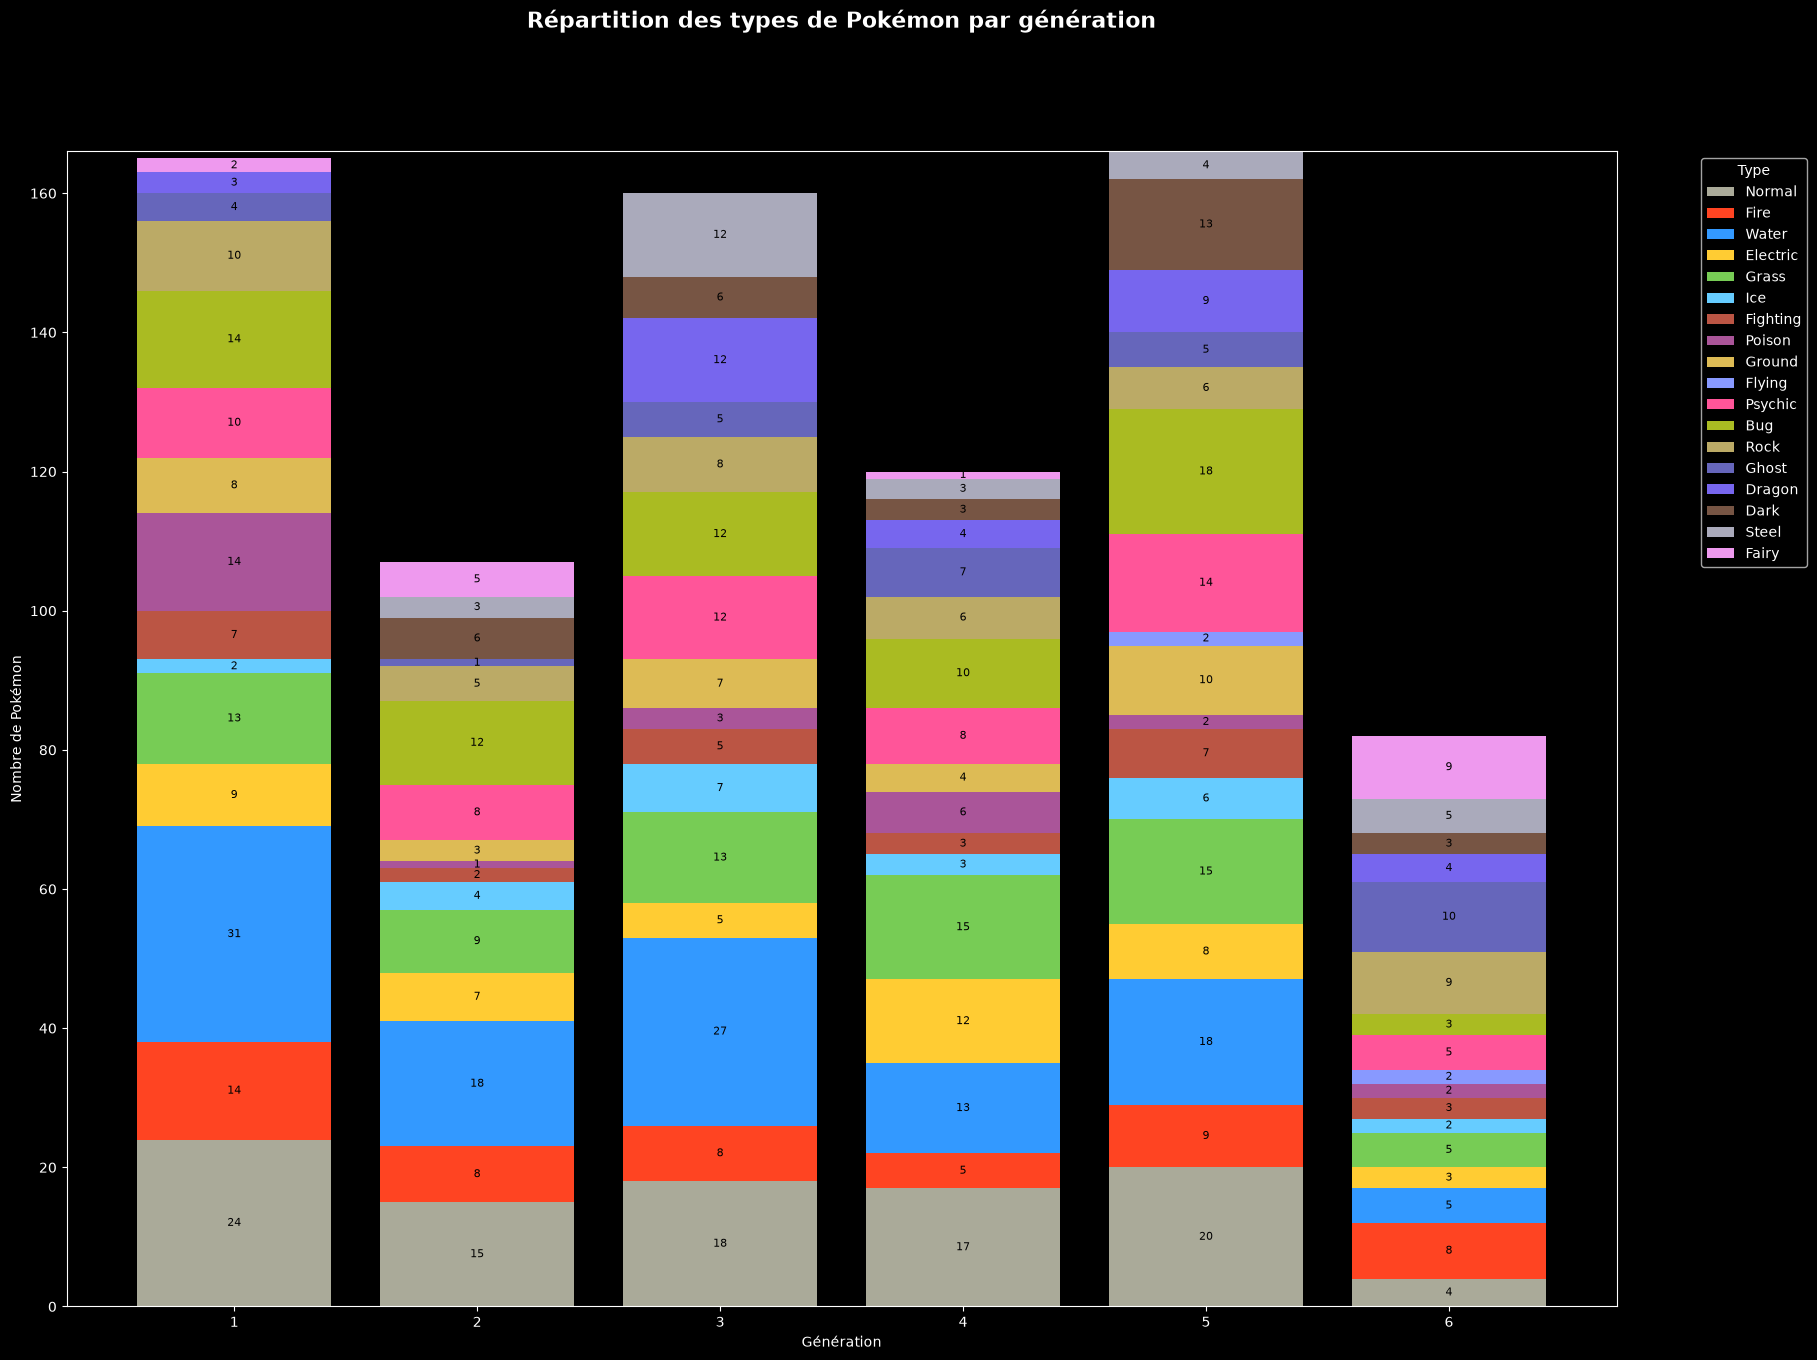

In [1276]:
df_gen_types = (
    df.groupby("Generation")["Type 1"]
    .value_counts()
    .unstack(fill_value=0)
)

df_gen_types = df_gen_types[
    [t for t in type_colors.keys() if t in df_gen_types.columns]
]


fig, ax = plt.subplots(figsize=(20, 15))

bottom = np.zeros(len(df_gen_types))

for pokemon_type in df_gen_types.columns:

    values = df_gen_types[pokemon_type]

    labels = [str(v) if v != 0 else "" for v in values]

    p = ax.bar(
        df_gen_types.index,
        values,
        bottom=bottom,
        label=pokemon_type,
        color=type_colors[pokemon_type]
    )

    ax.bar_label(p, labels=labels, label_type="center", color="black", fontsize=8)

    bottom += values

ax.set_xlabel("Génération")
ax.set_ylabel("Nombre de Pokémon")
ax.set_title("Répartition des types de Pokémon par génération", weight='bold', size=16, y=1.1)
ax.legend(
    title="Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

#### Graphiques des Pokémon les plus forts

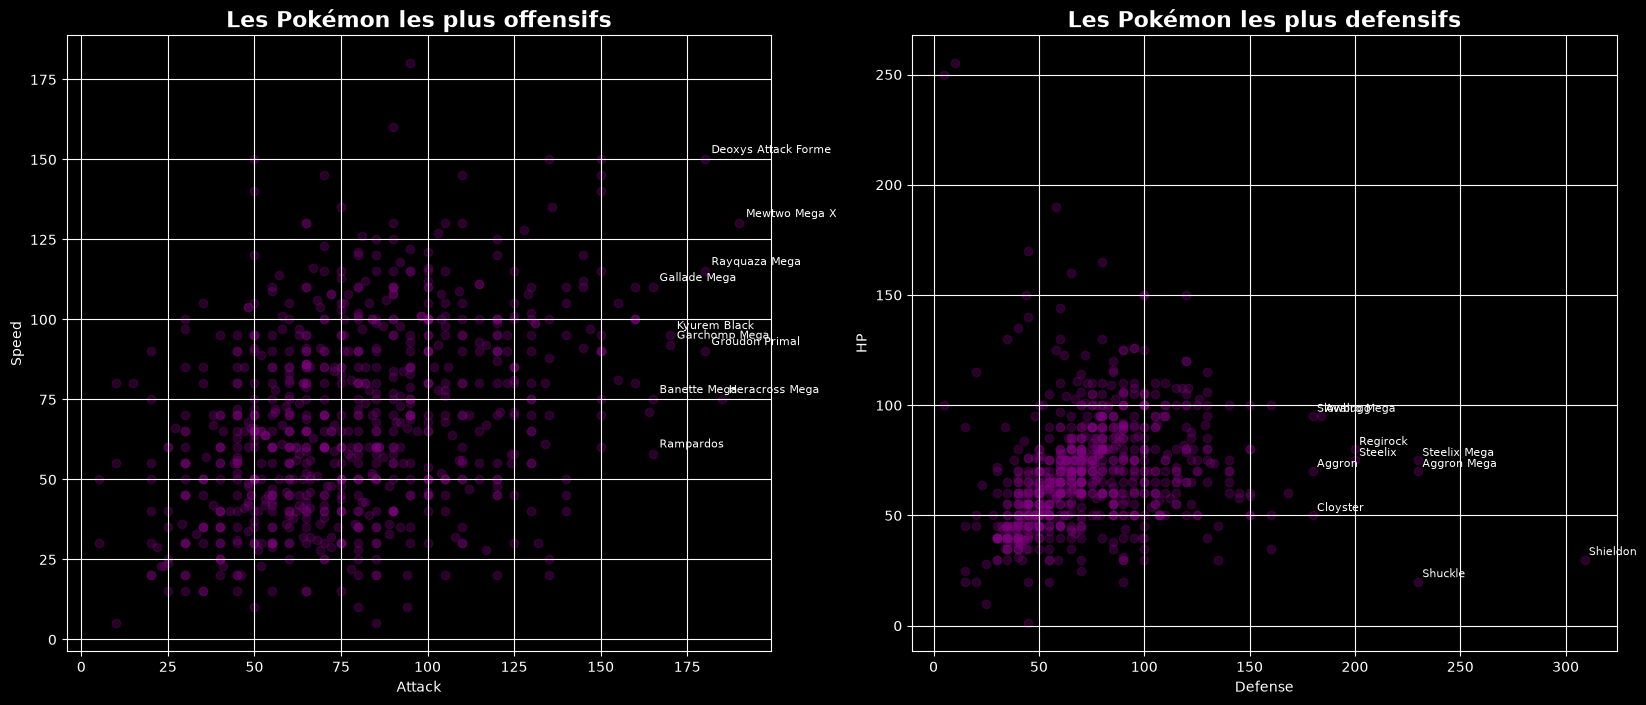

In [1277]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

ax[0].scatter(df["Attack"], df["Speed"], color="purple", alpha=0.3)
ax[0].set_xlabel("Attack")
ax[0].set_ylabel("Speed")
ax[0].set_title("Les Pokémon les plus offensifs", weight='bold', size=16)
ax[0].grid()
for _, row in df.nlargest(10, "Attack").iterrows():
    ax[0].text(row["Attack"] + 2, row["Speed"] + 2, row["Name"], fontsize=8)


ax[1].scatter(df["Defense"], df["HP"], color="purple", alpha=0.3)
ax[1].set_xlabel("Defense")
ax[1].set_ylabel("HP")
ax[1].set_title("Les Pokémon les plus defensifs", weight='bold', size=16)
ax[1].grid()
for _, row in df.nlargest(10, "Defense").iterrows():
    ax[1].text(row["Defense"] + 2, row["HP"] + 2, row["Name"], fontsize=8)
plt.show()

#### Graphique des HP des Pokémon

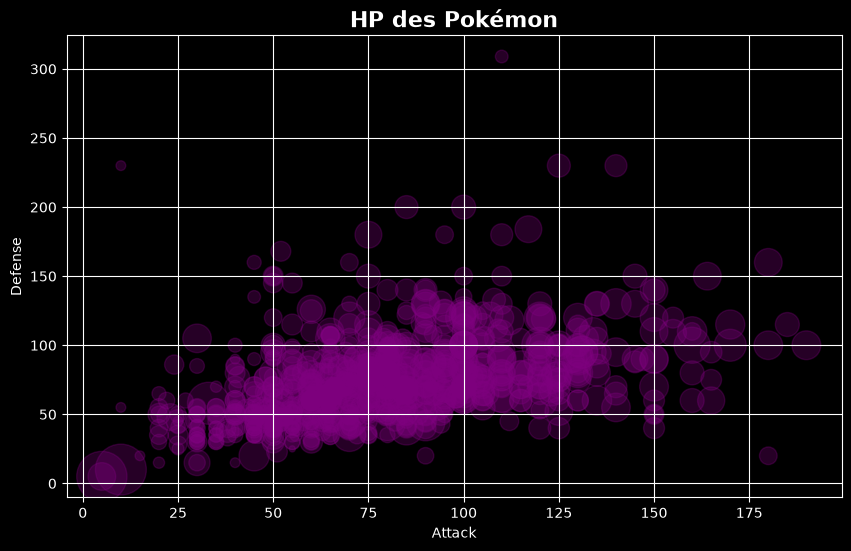

In [1278]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Attack"],
    df["Defense"],
    s=df["HP"]**1.3,
    alpha=0.3,
    color="purple"
)

plt.xlabel("Attack")
plt.ylabel("Defense")
plt.grid()
plt.title("HP des Pokémon", weight='bold', size=16)
plt.show()

#### Graphique des corrélations

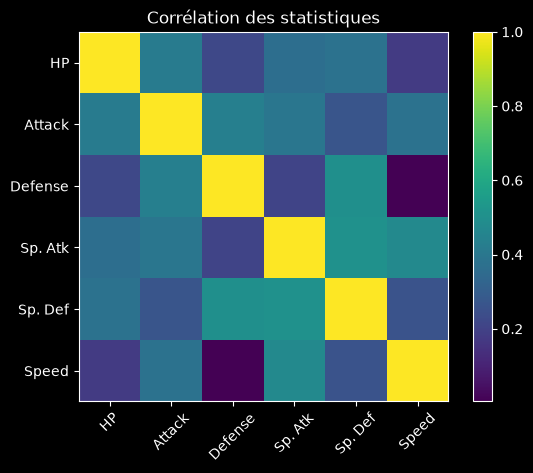

In [1279]:
corr = df[stats].corr()

plt.imshow(corr)
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar()
plt.title("Corrélation des statistiques")
plt.show()

#### Graphiques de la puissance des Pokémon

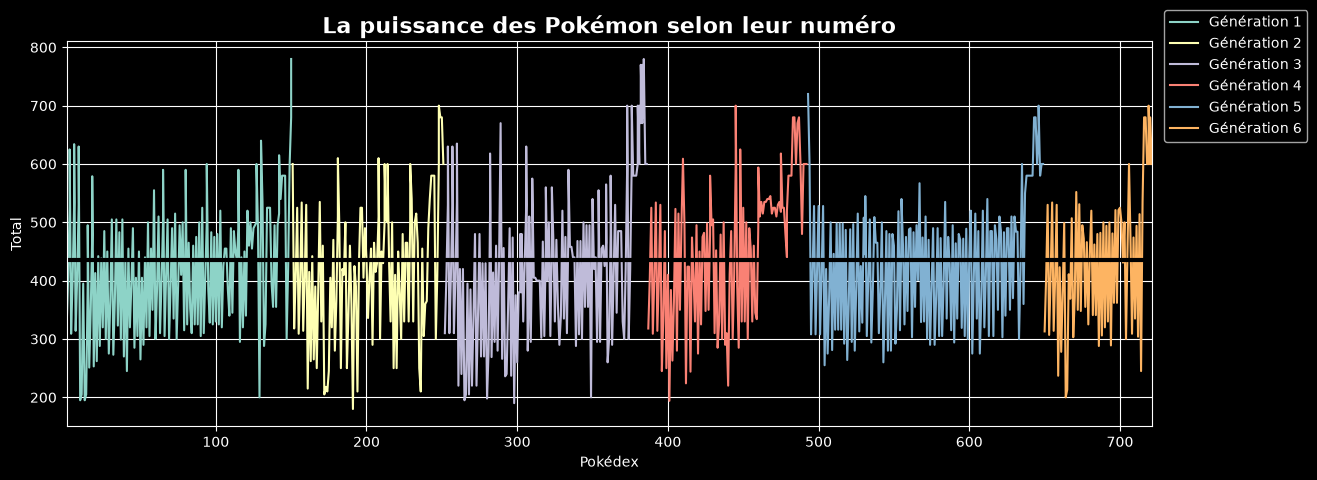

In [1280]:
total = df["#"].unique()

# masque_gen = (df["Generation"] == 1)
# print(df.loc[masque_gen, "Total"])


plt.figure(figsize=(14,5))
for i in range(1, 7):
    masque_gen = (df["Generation"] == i)
    plt.plot(
        df.loc[masque_gen, "#"],
        df.loc[masque_gen, "Total"],
        label=f"Génération {i}"
    )
plt.axhline(df["Total"].mean(), color="black", linewidth=3)
plt.title("La puissance des Pokémon selon leur numéro", weight='bold', size=16)
plt.grid()
plt.xlim(1, total.max())
plt.xlabel("Pokédex")
plt.ylabel("Total")
plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.15, 1.1)
)
plt.show()

#### Graphique de comparaison des Pokémon nooooobs avec les Légendaires

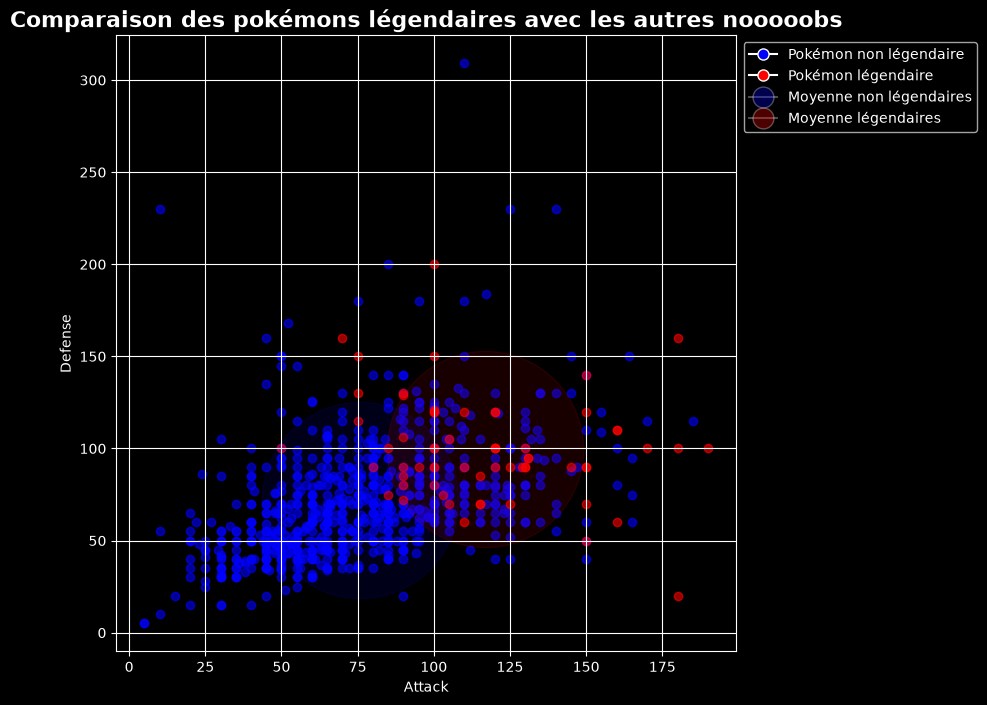

In [1281]:
plt.figure(figsize=(8,8))

masque_legendaire = df["Legendary"] == True
df_legendaire = df.loc[masque_legendaire]
df_non_legendaire = df.loc[~masque_legendaire]

plt.scatter(
    df_non_legendaire["Attack"], 
    df_non_legendaire["Defense"], 
    alpha=0.6, 
    color="blue",
    label="Pokémons non légendaires"
)
plt.scatter(
    df_legendaire["Attack"], 
    df_legendaire["Defense"], 
    alpha=0.6, 
    color="red",
    label="Pokémons légendaires"
)

plt.scatter(
    df_non_legendaire["Attack"].mean(), 
    df_non_legendaire["Defense"].mean(), 
    alpha=0.1, 
    color="blue", 
    s=20000,
    label="Moyenne des non légendaires"
)
plt.scatter(
    df_legendaire["Attack"].mean(), 
    df_legendaire["Defense"].mean(), 
    alpha=0.1, 
    color="red", 
    s=20000,
    label="Moyenne des légendaires"
)

# plt.axvline(df["Attack"].mean(), linestyle="--", color="darkblue")
# plt.axhline(df["Defense"].mean(), linestyle="--", color="darkblue")
plt.xlabel("Attack")
plt.ylabel("Defense")
plt.grid()
plt.title("Comparaison des pokémons légendaires avec les autres nooooobs", weight='bold', size=16)

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='Pokémon non légendaire',
           markerfacecolor='blue', markersize=8),

    Line2D([0], [0], marker='o', color='w',
           label='Pokémon légendaire',
           markerfacecolor='red', markersize=8),

    Line2D([0], [0], marker='o', color='w',
           label='Moyenne non légendaires',
           markerfacecolor='blue', alpha=0.3, markersize=15),

    Line2D([0], [0], marker='o', color='w',
           label='Moyenne légendaires',
           markerfacecolor='red', alpha=0.3, markersize=15),
]

plt.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(1.4, 1)
)
plt.show()

#### ON PETE LE PC ?

In [1282]:
# nb_col = 4
# nb_row = len(df) / nb_col

# for i in range(0, int(nb_row), nb_col):
#     id_pokemon = [
#         i+1,
#         i+2,
#         i+3,
#         i+4
#     ]

#     fig, axs = plt.subplots(1, 4, figsize=(20, 10), subplot_kw={"polar": True})

#     labels = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

#     # axs = axs.flatten()
#     for ax, id in zip(axs, id_pokemon):
#         pokemon = df.iloc[id]

#         values = pokemon[labels].astype(float).tolist()

#         values += values[:1]

#         angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
#         angles += angles[:1]

#         ax.plot(angles, values)
#         ax.set_ylim(0, df[labels].max().max())
#         ax.fill(angles, values, alpha=0.25)

#         ax.set_xticks(angles[:-1])
#         ax.set_xticklabels(labels)

#         ax.set_title(pokemon["Name"])

#     plt.show()

#### Graphique entre Attaque et Défense

Generation
1.0    150
2.0    251
3.0    386
4.0    492
5.0    649
6.0    721
Name: #, dtype: int64
Generation
1.0     75.363636
2.0    201.803738
3.0    321.968750
4.0    442.025000
5.0    573.783133
6.0    688.012195
Name: #, dtype: float64


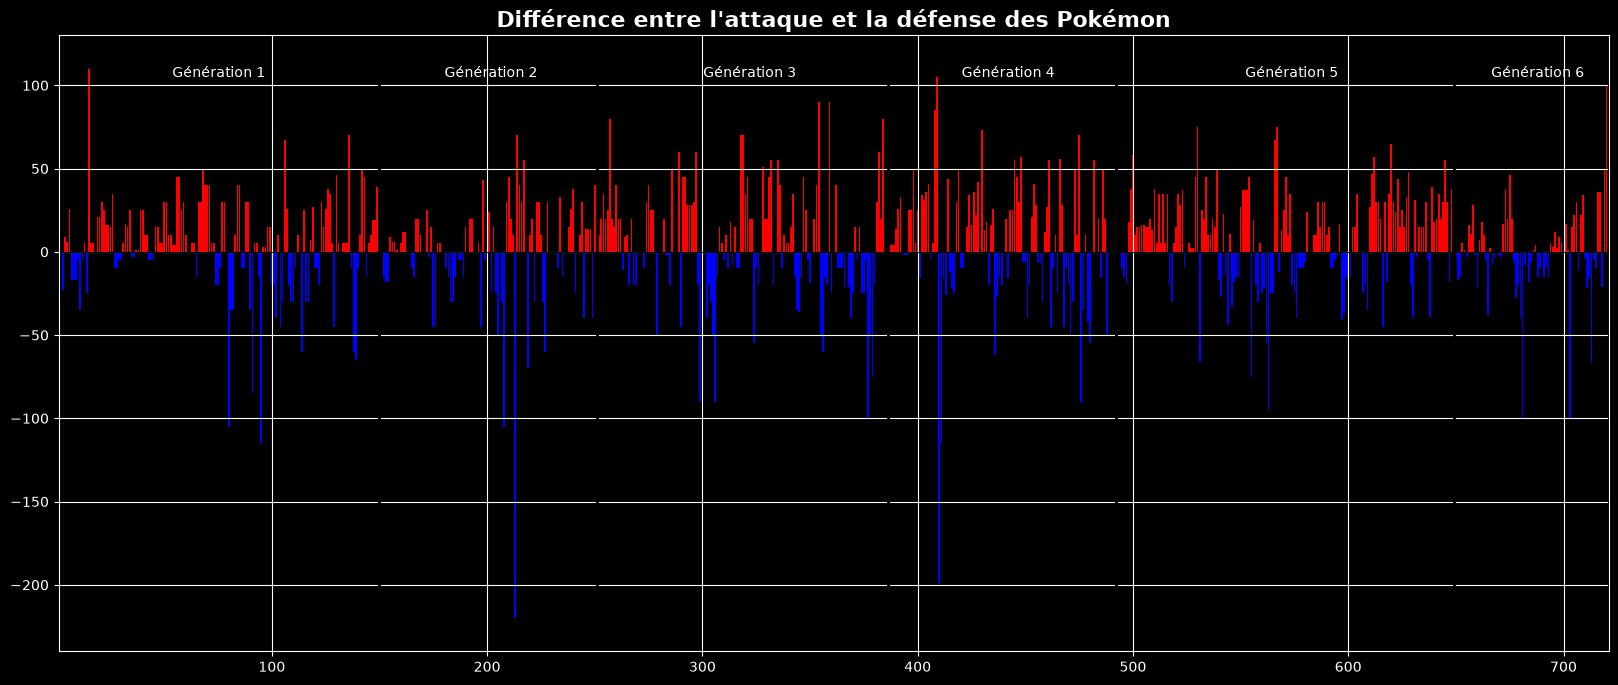

In [1283]:
df_last = df.groupby("#").last()
df_diff = df_last["Attack"] - df_last["Defense"]

df_max = df.groupby("Generation")["#"].max()
df_mean = df.groupby("Generation")["#"].mean()

print(df_max)
print(df_mean)
fig, ax = plt.subplots(figsize=(20, 8))
bar_colors = ['red', 'blue']

ax.bar(df_diff.index, df_diff.values, color=[bar_colors[0] if x > 0 else bar_colors[1] for x in df_diff.values])
ax.set_xlim(1, len(df_diff))
ax.set_ylim(df_diff.min()-20, df_diff.max()+20)
ax.set_title("Différence entre l'attaque et la défense des Pokémon", weight='bold', size=16)
for generation, last_pokemon in df_max.items():
    ax.axvline(last_pokemon, color='black', linewidth=2, label="test")
    ax.text(df_mean[generation], df_diff.max()-5, f'Génération {int(generation)}', ha='center')
ax.grid()
ax.axhline(0, color='black', linewidth=0.8)


plt.show()

#### Répartition des Légendaires dans les générations

0.6479534848028948 1.0 6 159
1.7160949870234246 2.0 5 102
2.764601535159018 3.0 18 142
3.8641589639154454 4.0 12 108
4.987278337573797 5.0 16 150
5.961172060186634 6.0 8 74


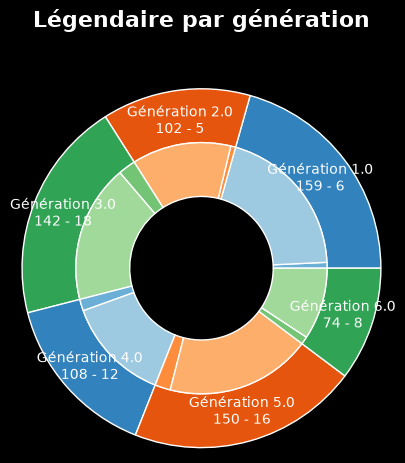

In [1284]:
df_legendaire_gen = df_legendaire.groupby("Generation")["Name"].count()
df_non_legendaire_gen = df_non_legendaire.groupby("Generation")["Name"].count()

legendaires = np.array([
    [total_legendaire, int(df_non_legendaire_gen[generation])] for generation, total_legendaire in df_legendaire_gen.items()
])

fig, ax = plt.subplots(subplot_kw=dict(projection="polar"))

size = 0.3
valsnorm = legendaires/np.sum(legendaires)*2*np.pi
valsleft = np.cumsum(np.append(0, valsnorm.flatten()[:-1])).reshape(legendaires.shape)

cmap = plt.colormaps["tab20c"]
outer_colors = cmap(np.arange(3)*4)
inner_colors = cmap([1, 2, 5, 6, 9, 10])

ax.bar(x=valsleft[:, 0],
       width=valsnorm.sum(axis=1), bottom=1-size, height=size,
       color=outer_colors, edgecolor='w', linewidth=1, align="edge")

ax.bar(x=valsleft.flatten(),
       width=valsnorm.flatten(), bottom=1-2*size, height=size,
       color=inner_colors, edgecolor='w', linewidth=1, align="edge")

angles = valsleft[:, 0] + valsnorm.sum(axis=1) / 2

for angle, generation, leg, non in zip(
    angles,
    df_legendaire_gen.index,
    df_legendaire_gen,
    df_non_legendaire_gen,
):
    print(angle, generation, leg, non)
    ax.text(
        angle,
        0.83,  # rayon où placer le texte
        f"Génération {generation}\n{non} - {leg}",
        ha="center",
        va="center",
        fontsize=10,
    )
ax.set_title("Légendaire par génération", weight='bold', size=16, y=1.13)
ax.set_axis_off()
plt.show()

#### Graphique Radar

In [ ]:
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

num_var = len(stats)

def radar_factory(num_vars, frame='circle'):
    """
    Create a radar chart with `num_vars` Axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle', 'polygon'}
        Shape of frame surrounding Axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarTransform(PolarAxes.PolarTransform):

        def transform_path_non_affine(self, path):
            # Paths with non-unit interpolation steps correspond to gridlines,
            # in which case we force interpolation (to defeat PolarTransform's
            # autoconversion to circular arcs).
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):

        name = 'radar'
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.append(x, x[0])
                y = np.append(y, y[0])
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)
                return {'polar': spine}
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta

if __name__ == '__main__':
    N = len(data_pokemon[0])
    theta = radar_factory(N, frame='polygon')
    spoke_labels = data_pokemon[0]
    data = data_pokemon[1:]
    colors = ['b', 'r', 'g', 'm', 'y', 'c', 'orange', 'purple', 'brown', 'pink']

    for title, names, case_data in data:
        graph = Pathlib("graphs") / f"{title}.png"

        if graph.is_file() == False:
            fig, ax = plt.subplots(
                figsize=(5, 5),
                subplot_kw=dict(projection='radar')
            )
            ax.set_ylim(
                0,
                max(max(stats) for stats in case_data)
                # df[stats].max().max()
            )
            ax.set_title(
                title.title(),
                weight='bold',
                size=16,
                y=1.1
            )
            for name, d, color in zip(names, case_data, colors):
                ax.plot(
                    theta,
                    d,
                    color=color,
                    label=name
                )
                ax.fill(
                    theta,
                    d,
                    facecolor=color,
                    alpha=0.25
                )
            ax.set_varlabels(spoke_labels)
            ax.legend(
                loc='upper right',
                bbox_to_anchor=(1.3, 1.1)
            )
            fig.savefig(f"graphs/{title}.png", dpi=300, bbox_inches="tight")
        
        # if graph.is_file():
        #     display(Image(f"graphs/{title}.png", width=500))

# TODO: Save graphe et mettre dans le df

C:\Users\Alexandre\AppData\Local\Temp\ipykernel_10764\4253659911.py:112: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(


#### Ajout des graphiques dans le dataframe

In [ ]:
graph_dir = Pathlib("graphs")

size = 200

df_graph = df["Evolution"].apply(
    lambda x: f'<img src="{(graph_dir / f"{x}.png").as_posix()}" width="{size}">'
)

index_total = df.columns.get_loc("Total")

df.insert(index_total, "Statistique", df_graph)


#### Fin

In [ ]:
display(HTML(df.to_html(escape=False)))

Id,#,Sprite,Shiny,Name,Evolution,Statistique,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Type 1,Type 2
0,1,,,Bulbasaur,Bulbasaur,,318.0,45.0,49.0,49.0,65.0,65.0,45.0,1.0,False,"Grass, Poison",Grass,Poison
1,2,,,Ivysaur,Bulbasaur,,405.0,60.0,62.0,63.0,80.0,80.0,60.0,1.0,False,"Grass, Poison",Grass,Poison
2,3,,,Venusaur,Bulbasaur,,525.0,80.0,82.0,83.0,100.0,100.0,80.0,1.0,False,"Grass, Poison",Grass,Poison
3,3,,,Venusaur Mega,Bulbasaur,,625.0,80.0,100.0,123.0,122.0,120.0,80.0,1.0,False,"Grass, Poison",Grass,Poison
4,4,,,Charmander,Charmander,,309.0,39.0,52.0,43.0,60.0,50.0,65.0,1.0,False,Fire,Fire,NaN
5,5,,,Charmeleon,Charmander,,405.0,58.0,64.0,58.0,80.0,65.0,80.0,1.0,False,Fire,Fire,NaN
6,6,,,Charizard,Charmander,,534.0,78.0,84.0,78.0,109.0,85.0,100.0,1.0,False,"Fire, Flying",Fire,Flying
7,6,,,Charizard Mega X,Charmander,,634.0,78.0,130.0,111.0,130.0,85.0,100.0,1.0,False,"Fire, Dragon",Fire,Dragon
8,6,,,Charizard Mega Y,Charmander,,634.0,78.0,104.0,78.0,159.0,115.0,100.0,1.0,False,"Fire, Flying",Fire,Flying
9,7,,,Squirtle,Squirtle,,314.0,44.0,48.0,65.0,50.0,64.0,43.0,1.0,False,Water,Water,NaN
